# 0. SETUP & IMPORTS (Install TIMM for Swin Transformer)

In [1]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import timm
except ImportError:
    print("Installing timm (PyTorch Image Models)...")
    install('timm')
    install('torchinfo')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import cv2
import random
from PIL import Image
from tqdm.notebook import tqdm
from itertools import cycle
from torchinfo import summary

# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


# 1. CONFIGURATION

In [2]:
# Parameters
DATA_DIR = '/kaggle/input/project-dataset-2/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Original_Dataset'
OUTPUT_DIR = "/kaggle/working/processed-dataset-swin"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 100 
PATIENCE = 8  # Swin converges differently, strict patience
LR = 1e-4     # Transformers need lower LR

# Seeds
SEED = 123
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# 2. DATA PREPROCESSING (Cache for Speed)

In [3]:
def prepare_data(data_dir, out_dir):
    data = []
    if not os.path.exists(data_dir): return [], []
    
    classes = sorted(os.listdir(data_dir))
    for cls in tqdm(classes, desc="Preprocessing"):
        src = os.path.join(data_dir, cls)
        dst = os.path.join(out_dir, cls)
        os.makedirs(dst, exist_ok=True)
        
        for f in os.listdir(src):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                in_p = os.path.join(src, f)
                out_p = os.path.join(dst, f)
                
                # Resize logic (skip if exists)
                if not os.path.exists(out_p):
                    try:
                        img = Image.open(in_p).convert('RGB').resize(IMG_SIZE, Image.Resampling.LANCZOS)
                        img.save(out_p, quality=95)
                    except: continue
                data.append((out_p, cls))
    return data, classes

file_list, class_names = prepare_data(DATA_DIR, OUTPUT_DIR)
df = pd.DataFrame(file_list, columns=['path', 'label'])

# Splits
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

Preprocessing:   0%|          | 0/3 [00:00<?, ?it/s]

# 3. DATALOADER SETUP

In [4]:
class BetelDS(Dataset):
    def __init__(self, dataframe, class_map, tfms=None):
        self.df = dataframe.reset_index(drop=True)
        self.tfms = tfms
        self.map = {c:i for i,c in enumerate(class_map)}
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row['path']).convert('RGB')
        if self.tfms: img = self.tfms(img)
        return img, self.map[row['label']]

# Transforms
stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
tf_train = transforms.Compose([
    transforms.RandomRotation(15), transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1), transforms.ToTensor(), transforms.Normalize(*stats)
])
tf_test = transforms.Compose([transforms.ToTensor(), transforms.Normalize(*stats)])

train_loader = DataLoader(BetelDS(train_df, class_names, tf_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(BetelDS(val_df, class_names, tf_test), batch_size=16, shuffle=False)
test_loader = DataLoader(BetelDS(test_df, class_names, tf_test), batch_size=16, shuffle=False)

print(f"Classes: {class_names}")
print(f"Train Size: {len(train_df)}")

Classes: ['Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot']
Train Size: 1425


# 2b. DATASET VISUALIZATION (Plots)


--- Dataset Split Statistics ---
Train: 1425 images (69.96%)
Validation: 306 images (15.02%)
Test: 306 images (15.02%)


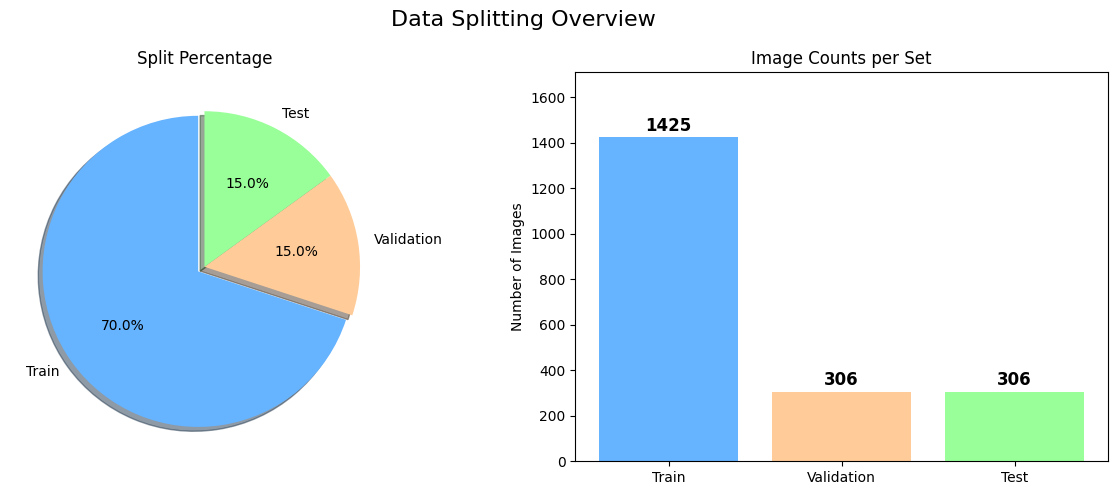

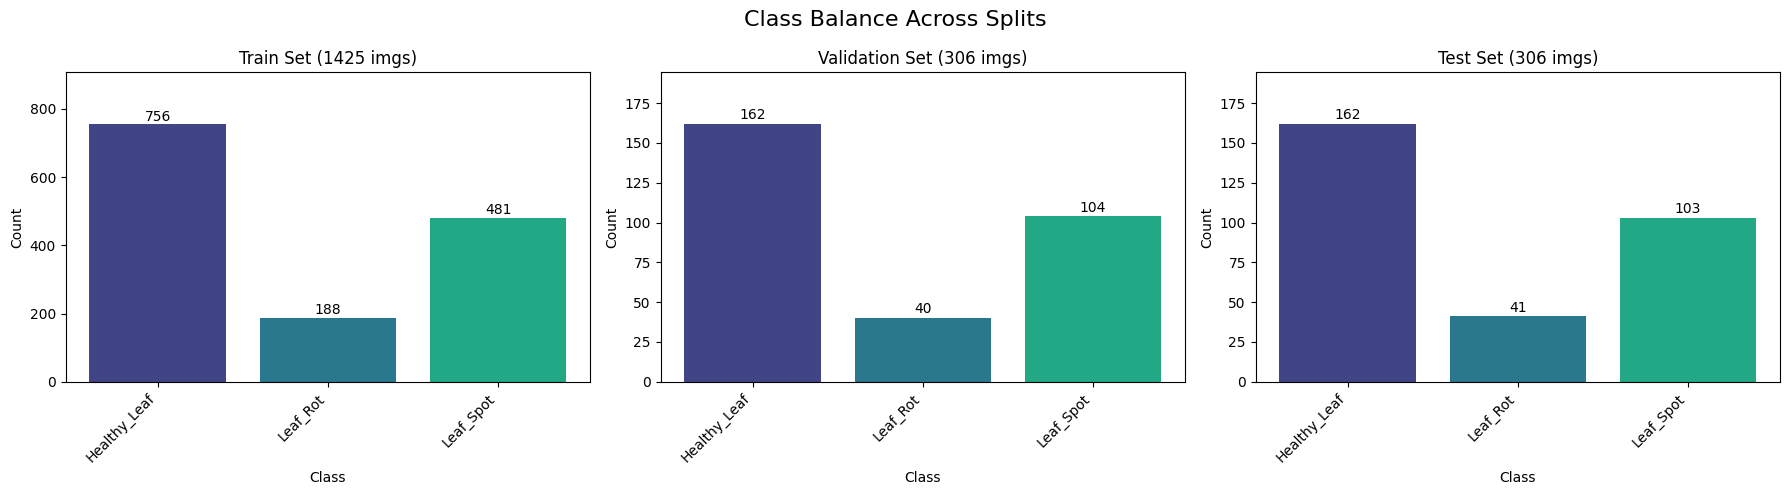

In [5]:
# 1. Dataset Split Ratios Visualization
sizes = {
    "Train": len(train_df),
    "Validation": len(val_df),
    "Test": len(test_df)
}
total = sum(sizes.values())

print("\n--- Dataset Split Statistics ---")
for split, size in sizes.items():
    print(f"{split}: {size} images ({size / total * 100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle("Data Splitting Overview", fontsize=16)

# Pie Chart
axes[0].pie(
    sizes.values(),
    labels=sizes.keys(),
    autopct="%.1f%%",
    startangle=90,
    colors=['#66b3ff', '#ffcc99', '#99ff99'],
    explode=(0.05, 0, 0), # Pop out train slice
    shadow=True
)
axes[0].set_title("Split Percentage")

# Bar Chart
bars = axes[1].bar(sizes.keys(), sizes.values(), color=['#66b3ff', '#ffcc99', '#99ff99'])
axes[1].set_ylabel("Number of Images")
axes[1].set_title("Image Counts per Set")
axes[1].set_ylim(0, max(sizes.values()) * 1.2)

# Add count labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
                 f'{height}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Class Distribution Visualization
def plot_class_distribution(train_df, val_df, test_df):
    datasets = {"Train": train_df, "Validation": val_df, "Test": test_df}
    colors = sns.color_palette("viridis", 4) # 4 classes
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Class Balance Across Splits', fontsize=16)
    
    for ax, (split_name, df) in zip(axes, datasets.items()):
        # Count per class (label column name matches my earlier Swin code 'label')
        class_counts = df['label'].value_counts().sort_index()

        # Bar Plot
        bars = ax.bar(class_counts.index, class_counts.values, color=colors)
        
        ax.set_title(f'{split_name} Set ({len(df)} imgs)')
        ax.set_xlabel('Class')
        ax.set_ylabel('Count')
        ax.set_xticks(range(len(class_counts)))
        ax.set_xticklabels(class_counts.index, rotation=45, ha='right')
        
        # Value labels
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')
            
        ax.set_ylim(0, max(class_counts) * 1.2) # Breathing room
    
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_df, val_df, test_df)

# 4. HYBRID MODEL (CNN + Swin Transformer)

In [6]:
print("\n--- Defining Hybrid Swin Transformer Model ---")

# We define a Swin Block manually wrapping Timm components or build a hybrid manually.
# Approach: Use a Pre-trained Swin-Tiny as Feature Extractor? Too heavy.
# Better: CNN stem -> Patch Embedding -> Swin Layer -> Head.

class SwinHybrid(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        
        # 1. CNN Stem (Standard Convolutional Front-end)
        # Purpose: Reduce spatial dimension (H/4, W/4) to act as Patch Embedding
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # 112x112
            nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 96, kernel_size=3, stride=2, padding=1), # 56x56
            nn.BatchNorm2d(96), nn.GELU()
        )
        
        # 2. Swin Transformer Blocks (Using Timm implementation parts for stability)
        # We load a tiny Swin and extract its stages.
        # Note: This is 'Transfer Learning' a transformer block specifically.
        swin_full = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)
        
        # We take the first 2 layers of Swin (keeps parameters low)
        # Swin tiny input expects 96 channels, which our CNN stem outputs. Perfect match.
        self.swin_layers = nn.Sequential(
            swin_full.layers[0], # Stage 1 (56x56)
            swin_full.layers[1]  # Stage 2 (28x28)
        )
        
        # 3. Post-Transformer Convolution (Project back to CNN friendly)
        # Stage 2 output channels = 192
        self.post_conv = nn.Sequential(
            nn.Conv2d(192, 256, 3, padding=1), # Project
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1) # Global Pool
        )
        
        # 4. Classifier Head
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Input: (B, 3, 224, 224)
        x = self.stem(x)              # -> (B, 96, 56, 56)
        
        # Swin expects (B, H, W, C). Our CNN output is (B, C, H, W).
        x = x.permute(0, 2, 3, 1)     # -> (B, 56, 56, 96)
        x = self.swin_layers(x)       # -> (B, 28, 28, 192)
        x = x.permute(0, 3, 1, 2)     # -> (B, 192, 28, 28)
        
        x = self.post_conv(x)         # -> (B, 256, 1, 1)
        x = self.head(x)
        return x

model = SwinHybrid(NUM_CLASSES).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
summary(model, input_size=(1, 3, 224, 224))


--- Defining Hybrid Swin Transformer Model ---


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Layer (type:depth-idx)                             Output Shape              Param #
SwinHybrid                                         [1, 4]                    --
├─Sequential: 1-1                                  [1, 96, 56, 56]           --
│    └─Conv2d: 2-1                                 [1, 32, 112, 112]         896
│    └─BatchNorm2d: 2-2                            [1, 32, 112, 112]         64
│    └─GELU: 2-3                                   [1, 32, 112, 112]         --
│    └─Conv2d: 2-4                                 [1, 96, 56, 56]           27,744
│    └─BatchNorm2d: 2-5                            [1, 96, 56, 56]           192
│    └─GELU: 2-6                                   [1, 96, 56, 56]           --
├─Sequential: 1-2                                  [1, 28, 28, 192]          --
│    └─SwinTransformerStage: 2-7                   [1, 56, 56, 96]           --
│    │    └─Identity: 3-1                          [1, 56, 56, 96]           --
│    │    └─Sequential: 3-2  

# 5. TRAINING


--- Training Start ---


Ep 1/100:   0%|          | 0/45 [00:00<?, ?it/s]

Ep 1: Tr_Acc=0.664 V_Acc=0.654 V_Loss=0.772


Ep 2/100:   0%|          | 0/45 [00:00<?, ?it/s]

Ep 2: Tr_Acc=0.766 V_Acc=0.758 V_Loss=0.580


...

Ep 36: Tr_Acc=0.959 V_Acc=0.954 V_Loss=0.142


Ep 37/100:   0%|          | 0/45 [00:00<?, ?it/s]

Ep 37: Tr_Acc=0.938 V_Acc=0.948 V_Loss=0.163


Ep 38/100:   0%|          | 0/45 [00:00<?, ?it/s]

Ep 38: Tr_Acc=0.950 V_Acc=0.944 V_Loss=0.202
Early Stopping


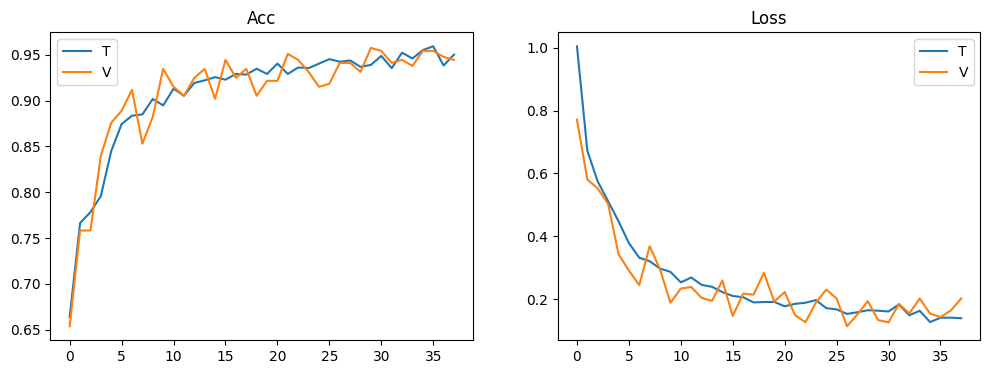

In [7]:
print("\n--- Training Start ---")
best_acc = 0
history = {'loss':[], 'acc':[], 'val_loss':[], 'val_acc':[]}
strikes = 0

for ep in range(EPOCHS):
    # Train
    model.train()
    l_sum, c, n = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Ep {ep+1}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        l_sum += loss.item(); _, p = torch.max(out, 1)
        c += (p==y).sum().item(); n += y.size(0)
        pbar.set_postfix({'loss': l_sum/n})
        
    tr_acc = c/n; tr_loss = l_sum/len(train_loader)
    
    # Val
    model.eval()
    vl_sum, vc, vn = 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            vl_sum += criterion(out, y).item(); _, p = torch.max(out, 1)
            vc += (p==y).sum().item(); vn += y.size(0)
    
    val_acc = vc/vn; val_loss = vl_sum/len(val_loader)
    
    # History
    history['acc'].append(tr_acc); history['val_acc'].append(val_acc)
    history['loss'].append(tr_loss); history['val_loss'].append(val_loss)
    
    print(f"Ep {ep+1}: Tr_Acc={tr_acc:.3f} V_Acc={val_acc:.3f} V_Loss={val_loss:.3f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "swin_hybrid_best.pth"))
        strikes = 0
    else:
        strikes += 1
        if strikes >= PATIENCE: 
            print("Early Stopping"); break

# Plots
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1); plt.plot(history['acc'], label='T'); plt.plot(history['val_acc'], label='V'); plt.legend(); plt.title('Acc')
plt.subplot(1,2,2); plt.plot(history['loss'], label='T'); plt.plot(history['val_loss'], label='V'); plt.legend(); plt.title('Loss')
plt.show()

# 6. EVALUATION (Confusion Matrix & Metrics)

Testing:   0%|          | 0/20 [00:00<?, ?it/s]

              precision    recall  f1-score   support

Healthy_Leaf       0.93      0.96      0.95       162
    Leaf_Rot       0.93      0.98      0.95        41
   Leaf_Spot       0.96      0.88      0.92       103

    accuracy                           0.94       306
   macro avg       0.94      0.94      0.94       306
weighted avg       0.94      0.94      0.94       306



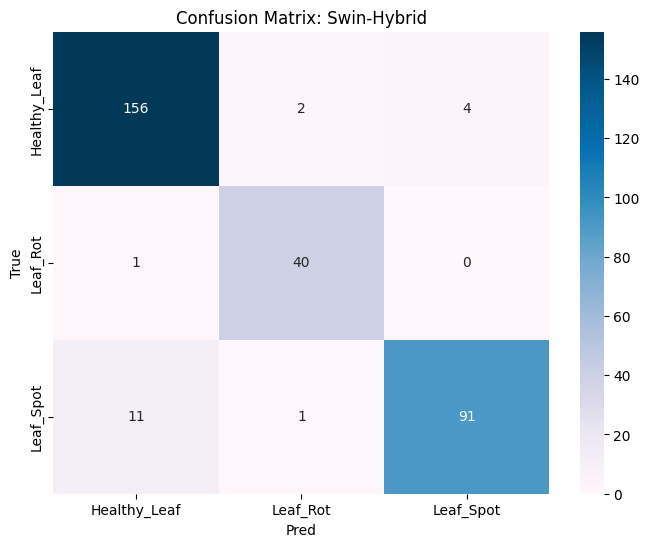

In [8]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "swin_hybrid_best.pth")))
model.eval()

all_y, all_p = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(device)
        out = model(x)
        all_y.extend(y.cpu().numpy())
        all_p.extend(out.argmax(1).cpu().numpy())

print(classification_report(all_y, all_p, target_names=class_names))

cm = confusion_matrix(all_y, all_p)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Swin-Hybrid')
plt.ylabel('True'); plt.xlabel('Pred')
plt.show()

# 7. ROC CURVE & AUC EVALUATION


--- Calculating ROC and AUC ---


ROC calculation:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


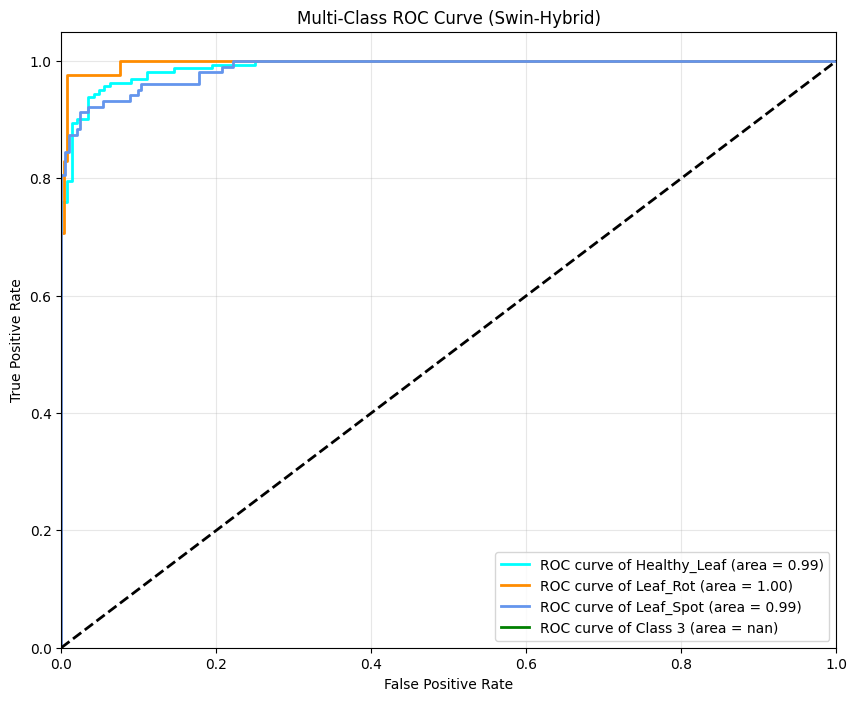

In [9]:
print("\n--- Calculating ROC and AUC ---")

# 1. Get Predictions (Probabilities)
model.eval()
y_true = []
y_score = [] 

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="ROC calculation"):
        x = x.to(device)
        # Forward pass
        outputs = model(x)
        # Apply softmax to get probabilities for each class
        probs = F.softmax(outputs, dim=1)
        
        y_true.extend(y.cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)

# 2. Binarize labels for One-vs-Rest ROC
# Converts scalar labels [0, 1, 2...] into binary matrix [[1,0,0], [0,1,0]...]
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
n_classes = y_bin.shape[1]

# 3. Compute ROC curve and AUC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple'])
lw = 2

for i, color in zip(range(n_classes), colors):
    # Use class name if available, else index
    label_name = class_names[i] if i < len(class_names) else f"Class {i}"
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of {0} (area = {1:0.2f})'.format(label_name, roc_auc[i]))

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (Swin-Hybrid)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


# 8. EXPLAINABILITY (Attention Rollout - Custom for Transformer)

#### Grad-CAM works best on CNNs. For Transformers, we look at Attention Maps.
#### However, Swin internal attention is complex to extract without deep hacks.
#### Since our model ends with a Convolution (self.post_conv), we CAN use Grad-CAM on that!
#### It will visualize what the model focuses on *after* the Transformer processing.


--- Visualizing Transformer Output Attention ---


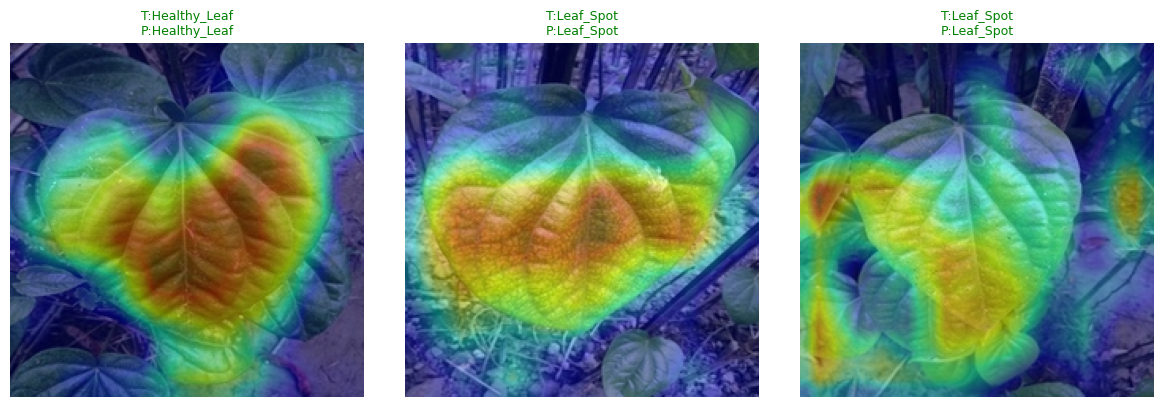

In [10]:
print("\n--- Visualizing Transformer Output Attention ---")

class GradCAM_Swin:
    def __init__(self, model):
        self.model = model
        self.grads = None; self.acts = None
        # Hook into 'post_conv[0]' (the conv layer after Swin)
        self.h1 = model.post_conv[0].register_forward_hook(self.f_hook)
        self.h2 = model.post_conv[0].register_full_backward_hook(self.b_hook)
    
    def f_hook(self, m, i, o): self.acts = o
    def b_hook(self, m, gi, go): self.grads = go[0]
    
    def run(self, x):
        self.model.zero_grad()
        out = self.model(x)
        target = out.argmax(1).item()
        out[:, target].backward()
        
        # Calc CAM
        w = torch.mean(self.grads, [0,2,3])
        # acts: (1, 256, 28, 28)
        cam = (self.acts[0] * w.view(-1,1,1)).sum(0)
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.detach().cpu().numpy(), target

    def close(self): self.h1.remove(); self.h2.remove()

gcam = GradCAM_Swin(model)

# Visualize 3 samples
iter_d = iter(test_loader)
imgs, lbls = next(iter_d)

plt.figure(figsize=(12, 4))
denorm = lambda x: np.clip(x.permute(1,2,0).cpu().numpy() * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)

for i in range(3):
    img_t = imgs[i].unsqueeze(0).to(device)
    map_, pred = gcam.run(img_t)
    
    orig = denorm(imgs[i])
    
    # Resize map to image
    # Ensure map_ is valid (no NaNs)
    if np.isnan(map_).any(): map_ = np.zeros((224,224))

    hmap = cv2.resize(map_, (224,224))
    
    # FIX: Changed to COLORMAP_JET which is universally available
    hmap = cv2.applyColorMap(np.uint8(255*hmap), cv2.COLORMAP_JET)
    hmap = cv2.cvtColor(hmap, cv2.COLOR_BGR2RGB)
    
    res = cv2.addWeighted(np.uint8(255*orig), 0.6, hmap, 0.4, 0)
    
    plt.subplot(1, 3, i+1)
    plt.imshow(res)
    t_name = class_names[lbls[i]]
    p_name = class_names[pred]
    col = 'green' if t_name==p_name else 'red'
    plt.title(f"T:{t_name}\nP:{p_name}", color=col, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()
gcam.close()